# Data Cleaning & Computation
Aug 18, 2022

Yuhan Ye

## Import all the necessary packages first

In [3]:
import os
import numpy as np
import pandas as pd
import spacy
import nltk
import re
import unicodedata
import string
import csv
import matplotlib.pyplot as plt
import seaborn as sns
import random
import xlrd

## Lower casing

- Convert everything to the lower case 

In [6]:
os.chdir("/Users/f0034w9/Dropbox (Dartmouth College)/Exercise Computational Linguistics/data/")

In [7]:
## start with a single file as example
##lower casing
with open('AccessPower10K2.txt', 'r') as file:
    string = file.read().replace('\n', '')
#string

In [8]:
stringlow=string.lower()  ## a built-in method used for string handling in Python
#stringlow

## Punctuation removal

- remove all the punctuation in the dataset (also remove @,%,#, and other special characters

In [9]:
string=stringlow
## punctuation removal
#string.punctuation contains !”#$%&\’()*+,-./:;<=>?@[\\]^_`{|}~
string_no_punct=re.sub(r'[^\w\s]','',string)
#string_no_punct

## Remove stop words

- The intuition behind using stop words is that, by removing low information words from the text, we can focus on the important words instead.
- We can also remove all short words (length < 2).
- We can also append other unnecessary words to stopwords list.

In [312]:
## As my sample of 44 firms is too small, if applying 5% rule to exclude buzz words, 
## the error can be relatively big
## thus I use a stopwords list

In [10]:
from nltk.corpus import stopwords
stopwords_list=stopwords.words('english')   ## 'english' is actually a list of buzz words
#stopwords_list

In [11]:
string = string_no_punct

string_no_stopwords = [word for word in string.split() if (word not in stopwords_list) and len(word) > 2]
string_no_stopwords=" ".join(string_no_stopwords)
#string_no_stopwords

## Word tokenization

In [12]:
from nltk.tokenize import word_tokenize

string_inp=string_no_stopwords
words = word_tokenize(string_inp)
tokens=string_inp.split()
#tokens

## Keep only nouns 

In [13]:
text=' '.join(tokens).lower()
tokens2 = nltk.word_tokenize(text)
tags = nltk.pos_tag(tokens2)
nouns = [word for word,pos in tags if (pos == 'NN' or pos == 'NNP' or pos == 'NNS' or pos == 'NNPS')
]
nouns=sorted(nouns)  #sort it alphabetically 
#nouns

## Return unique values from a list

In [14]:
myset = set(nouns)
#myset

# Next work on multiple files with for loop

In [318]:
# preparation for multiple files loop

In [319]:
## change the .txt file name 
# now the file names follow this pattern: 
### old:   2018\QTR1\20180103_10-K_edgar_data_1158420_0001144204-18-000327_1
### new name: 1158420_0001144204-18-000327_1 (contains CIK code： 1158420)

In [15]:
def get_numbers_from_filename(filename):
    #a=re.search('000.*18', filename).group(0)
    #b = a[:-3]
    print(filename)
    return '_'.join(filename.split('_')[-3:]).split('.')[0]
    #return b

In [16]:
#extract the CIK code for indexing
newname_example=get_numbers_from_filename('2018\QTR1\20180103_10-K_edgar_data_1158420_0001144204-18-000327_1')

2018\QTR180103_10-K_edgar_data_1158420_0001144204-18-000327_1


In [17]:
newname_example

'1158420_0001144204-18-000327_1'

In [18]:
pwd

'/Users/f0034w9/Dropbox (Dartmouth College)/Exercise Computational Linguistics/data'

In [19]:
os.chdir('./rantextsout')
path_of_the_directory='/Users/f0034w9/Dropbox (Dartmouth College)/Exercise Computational Linguistics/data/rantextsout'

In [20]:
dicts = {}  #use a dictionary to store all the word lists of firms
names = []

#load the 10-K files saved in local drive 'subtextsout' and clean the data
for filename in os.listdir(path_of_the_directory): ###need to set directory 
#     filename ='/Users/yuhanye/Desktop/subtextsout/2018\QTR1\20180227_10-K_edgar_data_1196501_0001171843-18-001503_1.txt'                                               ###to the data to run this
    if filename.endswith('.txt'):         #skip the .DS file in the folder
        ####%%%%%%%%%%% lower casing      ####%%%%%%%%%%%%%%%%%%%%%%%%%%%%    
        with open(filename, 'r') as file:
            string = file.read().replace('\n', '')
        #print(string)

        stringlow=string.lower()  ## a built-in method used for string handling in Python
        #print(stringlow)


        ####%%%%%%%%%%% punctuation removal  ####%%%%%%%%%%%%%%%%%%%%%%%%%%%
        string=stringlow
        ## punctuation removal
        #string.punctuation contains !”#$%&\’()*+,-./:;<=>?@[\\]^_`{|}~
        string_no_punct=re.sub(r'[^\w\s]','',string)
        #print(string_no_punct)


        ####%%%%%%%%%%%%%%% Remove stop words ####%%%%%%%%%%%%%%%%%%%%%%%%%%
        stopwords_list=stopwords.words('english')   ## 'english' is actually a list of buzz words
        #stopwords_list
        string = string_no_punct

        string_no_stopwords = [word for word in string.split() if (word not in stopwords_list) and len(word) > 2]
        string_no_stopwords=" ".join(string_no_stopwords)
        #string_no_stopwords
        
        
        ####%%%%%%%%%%%%%%% word tokenization ####%%%%%%%%%%%%%%%%%%%%%%%%%%
        from nltk.tokenize import word_tokenize
        string_inp=string_no_stopwords
        words = word_tokenize(string_inp)
        tokens=string_inp.split()
        #print(tokens)
        
        
        ####%%%%%%%%%%%%%%%   keep only nouns    ####%%%%%%%%%%%%%%%%%%%%%%%%%%
        text=' '.join(tokens).lower()
        tokens2 = nltk.word_tokenize(text)
        tags = nltk.pos_tag(tokens2)
        nouns = [word for word,pos in tags if (pos == 'NN' or pos == 'NNP' or pos == 'NNS' or pos == 'NNPS')
        ]
        nouns=sorted(nouns)  #sort it alphabetically 
        #print(nouns)
        
        ####%%%%%%%%%%%%%%%   Return unique values from list  ####%%%%%%%%%%%%%
        myset = set(nouns)   # set format
        
        
        ####%%%%%%%%%%%%%%%   rename the .txt file ####%%%%%%%%%%%%%
        newname=get_numbers_from_filename(filename)
        names.append(newname)
        
        dicts[newname] = myset
        
        

2018_QTR1_20180215_10-K_edgar_data_1178670_0001564590-18-002152_1.txt
2018_QTR1_20180226_10-K_edgar_data_1164863_0001164863-18-000009_1.txt
2018_QTR1_20180227_10-K_edgar_data_1171759_0001171759-18-000007_1.txt
2018_QTR1_20180228_10-K_edgar_data_1169770_0001169770-18-000004_1.txt
2018_QTR1_20180223_10-K_edgar_data_1171825_0001628280-18-002139_1.txt
2018_QTR1_20180227_10-K_edgar_data_1175505_0001564590-18-003511_1.txt
2018_QTR1_20180228_10-K_edgar_data_1174922_0001174922-18-000019_1.txt
2018_QTR1_20180228_10-K_edgar_data_1185348_0001185348-18-000008_1.txt
2018_QTR1_20180308_10-K_edgar_data_1175151_0001144204-18-013618_1.txt
2018_QTR1_20180330_10-K_edgar_data_1183765_0001564590-18-007268_1.txt
2018_QTR1_20180301_10-K_edgar_data_1175454_0001175454-18-000007_1.txt
2018_QTR1_20180221_10-K_edgar_data_1163302_0001163302-18-000011_1.txt
2018_QTR1_20180213_10-K_edgar_data_1172222_0001172222-18-000017_1.txt
2018_QTR1_20180301_10-K_edgar_data_1178879_0001047469-18-001199_1.txt
2018_QTR1_20180306_1

In [378]:
#print(dicts)   

In [21]:
len(dicts.keys())      #equal to number of firms in the sample 

56

In [22]:
len(names)         #equal to number of firms in the sample 

56

In [381]:
#dicts

## Generate corpus

In [23]:
#generate our specific corpus by merging word lists of all firms 
total_tokens = []
for key in dicts.keys():
    total_tokens += list(dicts[key])
total_tokens = set(total_tokens)
total_tokens=sorted(total_tokens)  #sort it alphabetically 
#total_tokens      #see our corpus 

In [24]:
len(total_tokens)       #we extracted this number of unique words from our sample data

12145

## Word presence: 0 or 1, saved in matrix 

In [25]:
# write a matrix collecting all the presence of each word for each company
one_hot_matrix = np.zeros((len(dicts.keys()),len(total_tokens)))
for j, token in enumerate(total_tokens):
    for i, key in enumerate(dicts.keys()):
        if token in dicts[key]:
            one_hot_matrix[i,j] = 1       

In [26]:
one_hot_matrix

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [27]:
pwd

'/Users/f0034w9/Dropbox (Dartmouth College)/Exercise Computational Linguistics/data/rantextsout'

In [28]:
# os.chdir('/Users/yuhanye/Desktop')
# path_of_the_directory='/Users/yuhanye/Desktop'
binary=pd.DataFrame(one_hot_matrix,columns=list(total_tokens),index=dicts.keys()).transpose()
binary.to_csv('../binary.csv')

binary

,1178670_0001564590-18-002152_1,1164863_0001164863-18-000009_1,1171759_0001171759-18-000007_1,1169770_0001169770-18-000004_1,1171825_0001628280-18-002139_1,1175505_0001564590-18-003511_1,1174922_0001174922-18-000019_1,1185348_0001185348-18-000008_1,1175151_0001144204-18-013618_1,1183765_0001564590-18-007268_1,...,1163739_0001558370-18-001382_1,1173514_0001173514-18-000014_1,1169445_0001169445-18-000006_1,1192448_0001558370-18-001301_1,1179060_0001179060-18-000003_1,1166003_0001166003-18-000022_1,1177702_0001564590-18-002882_1,1178253_0001564590-18-005461_1,1164727_0001558370-18-000894_1,1169987_0001564590-18-006602_1
03450___________aexelons,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
040securities,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10130premiums,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10contractors,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
10ptbanks,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zoo,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
zpak,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
zur,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
zyvox,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Show word distribution

In [29]:
#Make new column in dataframe "binary" by adding values from all other columns
binary['words'] = binary.sum(axis=1)  
#pay attention, when you run this multiple times, 
#the sum will also add up multiple times
#binary

In [30]:
distribution = binary['words'].to_frame()   #convert the extracted series to dataframe
distribution = distribution.sort_values(['words'], ascending=[False])
top10=distribution.head(10)  #we can see the top 10 words used in our sample
top10

,words
item,56.0
company,55.0
information,55.0
business,55.0
part,54.0
management,54.0
services,54.0
states,53.0
addition,53.0
report,53.0


In [31]:
top10.transpose()

,item,company,information,business,part,management,services,states,addition,report
words,56.0,55.0,55.0,55.0,54.0,54.0,54.0,53.0,53.0,53.0


In [32]:
top10
top10.index.name = 'counts'
top10.reset_index(inplace=True) #convert index to column 

In [33]:
top10

,counts,words
0,item,56.0
1,company,55.0
2,information,55.0
3,business,55.0
4,part,54.0
5,management,54.0
6,services,54.0
7,states,53.0
8,addition,53.0
9,report,53.0


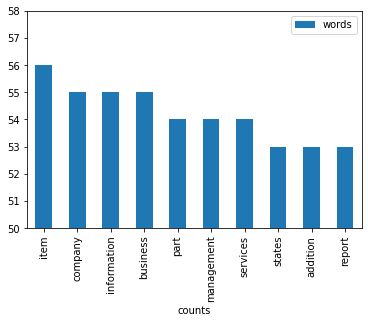

In [34]:
plotdata = pd.DataFrame(
    top10)
# Plot a bar chart
plotdata.plot(kind="bar", ylim=[50, 58], x='counts')
plt.savefig('top10.png', transparent=True)


# Words summary statistics

In [35]:
distribution

,words
item,56.0
company,55.0
information,55.0
business,55.0
part,54.0
...,...
glover,1.0
glycogen,1.0
glycoprotein,1.0
glyoxylate,1.0


In [36]:
distribution.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
words,12145.0,3.636805,6.905911,1.0,1.0,1.0,3.0,56.0


## Compute pairwise cosine similarity score

In [395]:
# it will be a n*n matrix
# n is number of companies

In [37]:
from sklearn.metrics.pairwise import cosine_similarity
similarity = cosine_similarity(one_hot_matrix)

In [38]:
df=pd.DataFrame(similarity,columns=dicts.keys(),index=dicts.keys())
#print(df)
df.to_csv('../similarity.csv')       

### Change matrix format to same format 
### as TNIC score on Hoberg-Philips Library

In [39]:
dicts_cik = {}  #use a dictionary to store all the word lists of firms 
names_cik = []

#extract CIK code of firms
for key in dicts.keys():
    CIK_code=key.split('_')[0].split('-')[0].lstrip("0")
    #print(CIK_code)
    newname=CIK_code
    names_cik.append(newname) 
    dicts_cik[newname] = myset

In [40]:
dicts   # check if the renaming is good

{'1178670_0001564590-18-002152_1': {'synthesis',
  'modalities',
  'category',
  'applicant',
  'backups',
  'ribopharma',
  'consortium',
  'user',
  'south',
  'america',
  'concerns',
  'bleeds',
  'role',
  'website',
  'august',
  'plans',
  'origin',
  'doxycycline',
  'urgent',
  'elevations',
  'thereunder',
  'endpoints',
  'schemes',
  'addition',
  'facility',
  'harmonization',
  'manufacture',
  'extension',
  'givosiran',
  'p00173',
  'copy',
  'conference',
  'deposits',
  'australia',
  'registration',
  'medicinal',
  'expire',
  'hires',
  'purity',
  'lendeckel',
  'ag10',
  'support',
  'practice',
  'property',
  'p182',
  'at3',
  'merck',
  'entity',
  'opt',
  'forces',
  'lipids',
  'heart',
  'ratio',
  'instances',
  'stcgalnacconjugate',
  'physicians',
  'transparency',
  'dates',
  'acts',
  'food',
  'assessment',
  'infection',
  'set',
  'resources',
  'ema',
  'life',
  'goal',
  'baseline',
  'portions',
  'medications',
  'advertising',
  'asia',
  

In [400]:
#dicts_cik

In [41]:
len_keys = len(dicts_cik.keys())
list_keys = list(dicts_cik.keys())
list_company1 = []
list_company2 = []
list_similarity = []
for i in range(len_keys):
    for j in range(i+1,len_keys):
        list_company1.append(list_keys[i])
        list_company2.append(list_keys[j])
        list_similarity.append(similarity[i,j])
pairwise_similarity = {'company1': list_company1, \
                       'company2': list_company2,\
                       'similarity': list_similarity}
pairwise_similarity = pd.DataFrame(pairwise_similarity)

In [42]:
pairwise_similarity #cik code

,company1,company2,similarity
0,1178670,1164863,0.249965
1,1178670,1171759,0.299800
2,1178670,1169770,0.315514
3,1178670,1171825,0.323313
4,1178670,1175505,0.477362
...,...,...,...
1535,1177702,1164727,0.225524
1536,1177702,1169987,0.310784
1537,1178253,1164727,0.183857
1538,1178253,1169987,0.417809


# Map the CIK code with GVKEY

In [44]:
pwd

'/Users/f0034w9/Dropbox (Dartmouth College)/Exercise Computational Linguistics/data/rantextsout'

In [45]:
#load the universe mappings of CIK and gvkey codes
columns = ["gvkey", "cik"]
df = pd.read_excel("../Map_gvkey_cik.xlsm", usecols=columns)

#sort dataframe by index in ascending order

# df=df.set_index('cik')
df = df.sort_index(ascending=False)
df.to_csv('../match.csv')  
# map_dict=df.T.to_dict('list')
# map_dict
mapping=df
mapping

,gvkey,cik
3674,1078,1800
3673,1084,1961
3672,1094,2034
3671,1097,2062
3670,1104,2098
...,...,...
4,151933,1190723
3,152071,1190935
2,254338,1191255
1,23990,1192448


In [46]:
pairwise_similarity1 = pairwise_similarity.rename(columns={'company1': 'cik'})
pairwise_similarity1

,cik,company2,similarity
0,1178670,1164863,0.249965
1,1178670,1171759,0.299800
2,1178670,1169770,0.315514
3,1178670,1171825,0.323313
4,1178670,1175505,0.477362
...,...,...,...
1535,1177702,1164727,0.225524
1536,1177702,1169987,0.310784
1537,1178253,1164727,0.183857
1538,1178253,1169987,0.417809


In [47]:
pairwise_similarity1['cik']=pairwise_similarity1['cik'].astype(str).astype(int)

In [48]:
pairwise_similarity2=pairwise_similarity1.merge(mapping, on='cik', how='inner')
pairwise_similarity2

,cik,company2,similarity,gvkey
0,1178670,1164863,0.249965,264265
1,1178670,1171759,0.299800,264265
2,1178670,1169770,0.315514,264265
3,1178670,1171825,0.323313,264265
4,1178670,1175505,0.477362,264265
...,...,...,...,...
1871,1177702,1164727,0.225524,150481
1872,1177702,1169987,0.310784,150481
1873,1178253,1164727,0.183857,20040
1874,1178253,1169987,0.417809,20040


In [49]:
pairwise_similarity3 = pairwise_similarity2.rename(columns={'gvkey': 'gvkey1'})
pairwise_similarity3

,cik,company2,similarity,gvkey1
0,1178670,1164863,0.249965,264265
1,1178670,1171759,0.299800,264265
2,1178670,1169770,0.315514,264265
3,1178670,1171825,0.323313,264265
4,1178670,1175505,0.477362,264265
...,...,...,...,...
1871,1177702,1164727,0.225524,150481
1872,1177702,1169987,0.310784,150481
1873,1178253,1164727,0.183857,20040
1874,1178253,1169987,0.417809,20040


In [50]:
pairwise_similarity4 = pairwise_similarity3.drop('cik', axis=1)
pairwise_similarity4

,company2,similarity,gvkey1
0,1164863,0.249965,264265
1,1171759,0.299800,264265
2,1169770,0.315514,264265
3,1171825,0.323313,264265
4,1175505,0.477362,264265
...,...,...,...
1871,1164727,0.225524,150481
1872,1169987,0.310784,150481
1873,1164727,0.183857,20040
1874,1169987,0.417809,20040


In [51]:
pairwise_similarity5 = pairwise_similarity4.rename(columns={'company2': 'cik'})
pairwise_similarity5

,cik,similarity,gvkey1
0,1164863,0.249965,264265
1,1171759,0.299800,264265
2,1169770,0.315514,264265
3,1171825,0.323313,264265
4,1175505,0.477362,264265
...,...,...,...
1871,1164727,0.225524,150481
1872,1169987,0.310784,150481
1873,1164727,0.183857,20040
1874,1169987,0.417809,20040


In [52]:
pairwise_similarity5['cik']=pairwise_similarity5['cik'].astype(str).astype(int)
pairwise_similarity6=pairwise_similarity5.merge(mapping, on='cik', how='inner')
pairwise_similarity6

,cik,similarity,gvkey1,gvkey
0,1164863,0.249965,264265,148950
1,1171759,0.299800,264265,148470
2,1171759,0.290762,148950,148470
3,1169770,0.315514,264265,149618
4,1169770,0.315514,264265,149618
...,...,...,...,...
2261,1169987,0.313091,150277,22713
2262,1169987,0.327666,144998,22713
2263,1169987,0.310784,150481,22713
2264,1169987,0.417809,20040,22713


In [53]:
pairwise_similarity7 = pairwise_similarity6.rename(columns={'gvkey': 'gvkey2'})
pairwise_similarity7

,cik,similarity,gvkey1,gvkey2
0,1164863,0.249965,264265,148950
1,1171759,0.299800,264265,148470
2,1171759,0.290762,148950,148470
3,1169770,0.315514,264265,149618
4,1169770,0.315514,264265,149618
...,...,...,...,...
2261,1169987,0.313091,150277,22713
2262,1169987,0.327666,144998,22713
2263,1169987,0.310784,150481,22713
2264,1169987,0.417809,20040,22713


In [54]:
pairwise_similarity8 = pairwise_similarity7.drop('cik', axis=1)
pairwise_similarity8

,similarity,gvkey1,gvkey2
0,0.249965,264265,148950
1,0.299800,264265,148470
2,0.290762,148950,148470
3,0.315514,264265,149618
4,0.315514,264265,149618
...,...,...,...
2261,0.313091,150277,22713
2262,0.327666,144998,22713
2263,0.310784,150481,22713
2264,0.417809,20040,22713


### Compare scores based on sample corpus and total corpus

In [413]:
df = pd.read_csv("tnic3_data.txt", sep="\t")
#filter, only keep year 2018
df2018=df.loc[df['year'] == 2018]

In [414]:
df2018.to_csv('df2018.csv') 
df2018

,year,gvkey1,gvkey2,score
22293478,2018,1004,1234,0.0166
22293479,2018,1004,1823,0.0166
22293480,2018,1004,4091,0.0460
22293481,2018,1004,5608,0.0094
22293482,2018,1004,6326,0.0124
...,...,...,...,...
23674261,2018,316056,316056,NaN
23674262,2018,317264,317264,NaN
23674263,2018,318728,318728,NaN
23674264,2018,326688,326688,NaN


In [415]:
pairwise_similarity9=pairwise_similarity8.merge(df2018, on=['gvkey1','gvkey2'], how='inner')
pairwise_similarity9.to_csv('pairwise_similarity9.csv') 
pairwise_similarity9

,similarity,gvkey1,gvkey2,year,score
0,0.408965,163965,18430,2018,0.0684
1,0.494111,149738,149618,2018,0.1545
2,0.494111,149738,149618,2018,0.1545
3,0.494111,149738,149618,2018,0.1545
4,0.494111,149738,149618,2018,0.1545
...,...,...,...,...,...
112,0.462867,15539,23990,2018,0.0992
113,0.438137,20040,23990,2018,0.0904
114,0.487462,22713,23990,2018,0.0772
115,0.294122,174647,147849,2018,0.0063


In [416]:
new_cols = ["year","gvkey1","gvkey2","similarity",'score']
pairwise_similarity10=pairwise_similarity9[new_cols]
pairwise_similarity10

,year,gvkey1,gvkey2,similarity,score
0,2018,163965,18430,0.408965,0.0684
1,2018,149738,149618,0.494111,0.1545
2,2018,149738,149618,0.494111,0.1545
3,2018,149738,149618,0.494111,0.1545
4,2018,149738,149618,0.494111,0.1545
...,...,...,...,...,...
112,2018,15539,23990,0.462867,0.0992
113,2018,20040,23990,0.438137,0.0904
114,2018,22713,23990,0.487462,0.0772
115,2018,174647,147849,0.294122,0.0063


In [417]:
pairwise_similarity11 = pairwise_similarity10.rename(columns={'similarity': 'score_sample'})
pairwise_similarity11

,year,gvkey1,gvkey2,score_sample,score
0,2018,163965,18430,0.408965,0.0684
1,2018,149738,149618,0.494111,0.1545
2,2018,149738,149618,0.494111,0.1545
3,2018,149738,149618,0.494111,0.1545
4,2018,149738,149618,0.494111,0.1545
...,...,...,...,...,...
112,2018,15539,23990,0.462867,0.0992
113,2018,20040,23990,0.438137,0.0904
114,2018,22713,23990,0.487462,0.0772
115,2018,174647,147849,0.294122,0.0063


In [420]:
pairwise_similarity12 = pairwise_similarity11.rename(columns={'score': 'score_total'})
pairwise_similarity12.to_csv('score_compare.csv') 
pairwise_similarity12

,year,gvkey1,gvkey2,score_sample,score_total
0,2018,163965,18430,0.408965,0.0684
1,2018,149738,149618,0.494111,0.1545
2,2018,149738,149618,0.494111,0.1545
3,2018,149738,149618,0.494111,0.1545
4,2018,149738,149618,0.494111,0.1545
...,...,...,...,...,...
112,2018,15539,23990,0.462867,0.0992
113,2018,20040,23990,0.438137,0.0904
114,2018,22713,23990,0.487462,0.0772
115,2018,174647,147849,0.294122,0.0063


In [419]:
pairwise_similarity12.describe()

,year,gvkey1,gvkey2,score_sample,score_total
count,117.0,117.000000,117.000000,117.000000,117.000000
mean,2018.0,122221.829060,60160.136752,0.449679,0.094615
std,0.0,57830.216044,58685.737036,0.053564,0.051669
min,2018.0,15539.000000,15539.000000,0.256343,0.002600
25%,2018.0,62139.000000,20040.000000,0.423923,0.057400
50%,2018.0,149738.000000,23450.000000,0.463878,0.092700
75%,2018.0,150279.000000,147849.000000,0.485059,0.132600
max,2018.0,264265.000000,185453.000000,0.538569,0.236800
